# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Target Variable:** `is_high_risk` (Classification Part A)

### Project Introduction
We train and evaluate all 5 required classification models individually on stratified train/test data.

In [14]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.utils as utils

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        if hasattr(X, 'toarray'):
            return X.toarray()
        return X

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Classification libraries loaded successfully.')

Classification libraries loaded successfully.


## Data Preprocessing and Stratified Split
Target variable `is_high_risk`. `risk_score` is dropped to prevent target leakage.

In [15]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_classification()
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)

cls_results = []
subsample_idx = np.random.choice(len(X_train), size=min(8000, len(X_train)), replace=False)
X_train_sub = X_train.iloc[subsample_idx]
y_train_sub = y_train.iloc[subsample_idx]

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)


### 1. Logistic Regression

In [16]:
c_lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
c_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [17]:
p_lr = c_lr.predict(X_test)
prob_lr = c_lr.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, p_lr),
    'Precision': precision_score(y_test, p_lr, zero_division=0),
    'Recall': recall_score(y_test, p_lr, zero_division=0),
    'Weighted F1': f1_score(y_test, p_lr, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_lr)
})
print('Logistic Regression complete.')

Logistic Regression complete.


### 2. K-Nearest Neighbors Classifier

In [18]:
c_knn = Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))])
c_knn.fit(X_train_sub, y_train_sub)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [19]:
p_knn = c_knn.predict(X_test)
prob_knn = c_knn.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'K-Nearest Neighbors',
    'Accuracy': accuracy_score(y_test, p_knn),
    'Precision': precision_score(y_test, p_knn, zero_division=0),
    'Recall': recall_score(y_test, p_knn, zero_division=0),
    'Weighted F1': f1_score(y_test, p_knn, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_knn)
})
print('KNN Classifier complete.')

KNN Classifier complete.


### 3. Gaussian Naive Bayes

In [20]:
c_gnb = Pipeline([('prep', preprocessor), ('to_dense', DenseTransformer()), ('clf', GaussianNB())])
c_gnb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('to_dense', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [21]:
p_gnb = c_gnb.predict(X_test)
prob_gnb = c_gnb.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Gaussian Naive Bayes',
    'Accuracy': accuracy_score(y_test, p_gnb),
    'Precision': precision_score(y_test, p_gnb, zero_division=0),
    'Recall': recall_score(y_test, p_gnb, zero_division=0),
    'Weighted F1': f1_score(y_test, p_gnb, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_gnb)
})
print('Gaussian Naive Bayes complete.')

Gaussian Naive Bayes complete.


### 4. Decision Tree Classifier

In [22]:
c_dt = Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))])
c_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [23]:
p_dt = c_dt.predict(X_test)
prob_dt = c_dt.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, p_dt),
    'Precision': precision_score(y_test, p_dt, zero_division=0),
    'Recall': recall_score(y_test, p_dt, zero_division=0),
    'Weighted F1': f1_score(y_test, p_dt, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_dt)
})
print('Decision Tree Classifier complete.')

Decision Tree Classifier complete.


### 5. Support Vector Classifier

In [24]:
c_svc = Pipeline([('prep', preprocessor), ('clf', CalibratedClassifierCV(SVC(C=1.0, random_state=42), ensemble=False))])
c_svc.fit(X_train_sub, y_train_sub)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [25]:
p_svc = c_svc.predict(X_test)
prob_svc = c_svc.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Support Vector Machine',
    'Accuracy': accuracy_score(y_test, p_svc),
    'Precision': precision_score(y_test, p_svc, zero_division=0),
    'Recall': recall_score(y_test, p_svc, zero_division=0),
    'Weighted F1': f1_score(y_test, p_svc, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_svc)
})
print('Support Vector Classifier complete.')

Support Vector Classifier complete.


## Classification Model Comparison
Consolidated metrics for all 5 classification algorithms:

In [26]:
df_cls = pd.DataFrame(cls_results).sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)
df_cls.index += 1
df_cls

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
1,Decision Tree,0.99795,0.997822,0.996601,0.997950,0.999579
2,Logistic Regression,0.99680,0.996866,0.994426,0.996799,0.999755
3,Support Vector Machine,0.96600,0.958769,0.948341,0.965961,0.996215
4,K-Nearest Neighbors,0.85860,0.913290,0.680125,0.853142,0.939874
5,Gaussian Naive Bayes,0.83615,0.784727,0.764138,0.835681,0.911299


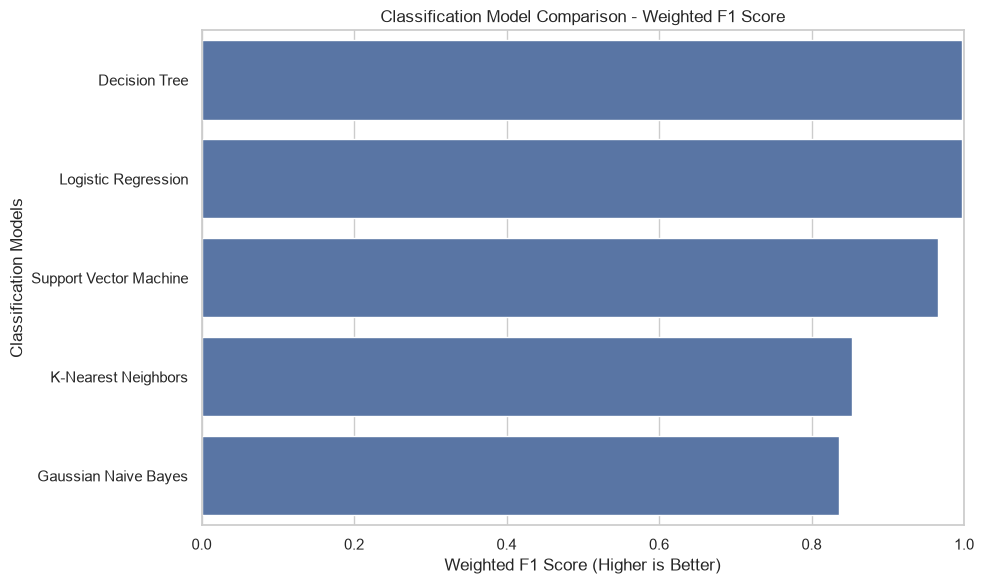

In [32]:
# Classification Model Comparison - Weighted F1 Score
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_cls,
    x='Weighted F1',
    y='Model'
)

plt.title('Classification Model Comparison - Weighted F1 Score')
plt.xlabel('Weighted F1 Score (Higher is Better)')
plt.ylabel('Classification Models')

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [33]:
# Select Best Classification Model
best_cls_model = df_cls.iloc[0]

print("===== BEST CLASSIFICATION MODEL =====")
print("Model     :", best_cls_model['Model'])
print("Accuracy  :", round(best_cls_model['Accuracy'], 4))
print("Precision :", round(best_cls_model['Precision'], 4))
print("Recall    :", round(best_cls_model['Recall'], 4))
print("F1 Score  :", round(best_cls_model['Weighted F1'], 4))
print("ROC-AUC   :", round(best_cls_model['ROC-AUC'], 4))

print(
    f"\nConclusion: {best_cls_model['Model']} is the best classification model "
    f"with Weighted F1 = {best_cls_model['Weighted F1']:.4f}, "
    f"Accuracy = {best_cls_model['Accuracy']:.4f}, "
    f"and ROC-AUC = {best_cls_model['ROC-AUC']:.4f}."
)

===== BEST CLASSIFICATION MODEL =====
Model     : Decision Tree
Accuracy  : 0.998
Precision : 0.9978
Recall    : 0.9966
F1 Score  : 0.9979
ROC-AUC   : 0.9996

Conclusion: Decision Tree is the best classification model with Weighted F1 = 0.9979, Accuracy = 0.9980, and ROC-AUC = 0.9996.


In [37]:
print("Cross-Validation")
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    c_dt,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

print("5-Fold CV Scores:", cv_scores)
print(f"Mean Weighted F1: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

5-Fold CV Scores: [0.99831265 0.99849973 0.99831241 0.997375   0.99793724]
Mean Weighted F1: 0.9981
Standard Deviation: 0.0004


In [41]:
print("Hyperparameter Tuning")
from sklearn.model_selection import RandomizedSearchCV

dt_param_grid = {
    'clf__max_depth': [5, 8, 10, 15, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy']
}

search_dt = RandomizedSearchCV(
    c_dt,
    param_distributions=dt_param_grid,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

search_dt.fit(X_train, y_train)

best_dt_model = search_dt.best_estimator_

print("Best Hyperparameters:")
print(search_dt.best_params_)

print(
    f"Best CV Weighted F1: "
    f"{search_dt.best_score_:.4f}"
)

Hyperparameter Tuning
Best Hyperparameters:
{'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_depth': 10, 'clf__criterion': 'entropy'}
Best CV Weighted F1: 0.9992


In [42]:
print("Evaluate Tuned Model")
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_tuned = best_dt_model.predict(X_test)

print("===== TUNED DECISION TREE =====")

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred_tuned), 4)
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_tuned,
            average='weighted'
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_pred_tuned,
            average='weighted'
        ),
        4
    )
)

print(
    "Weighted F1:",
    round(
        f1_score(
            y_test,
            y_pred_tuned,
            average='weighted'
        ),
        4
    )
)

Evaluate Tuned Model
===== TUNED DECISION TREE =====
Accuracy: 0.9995
Precision: 0.9995
Recall: 0.9995
Weighted F1: 0.9995


## Confusion Matrices and ROC Curve

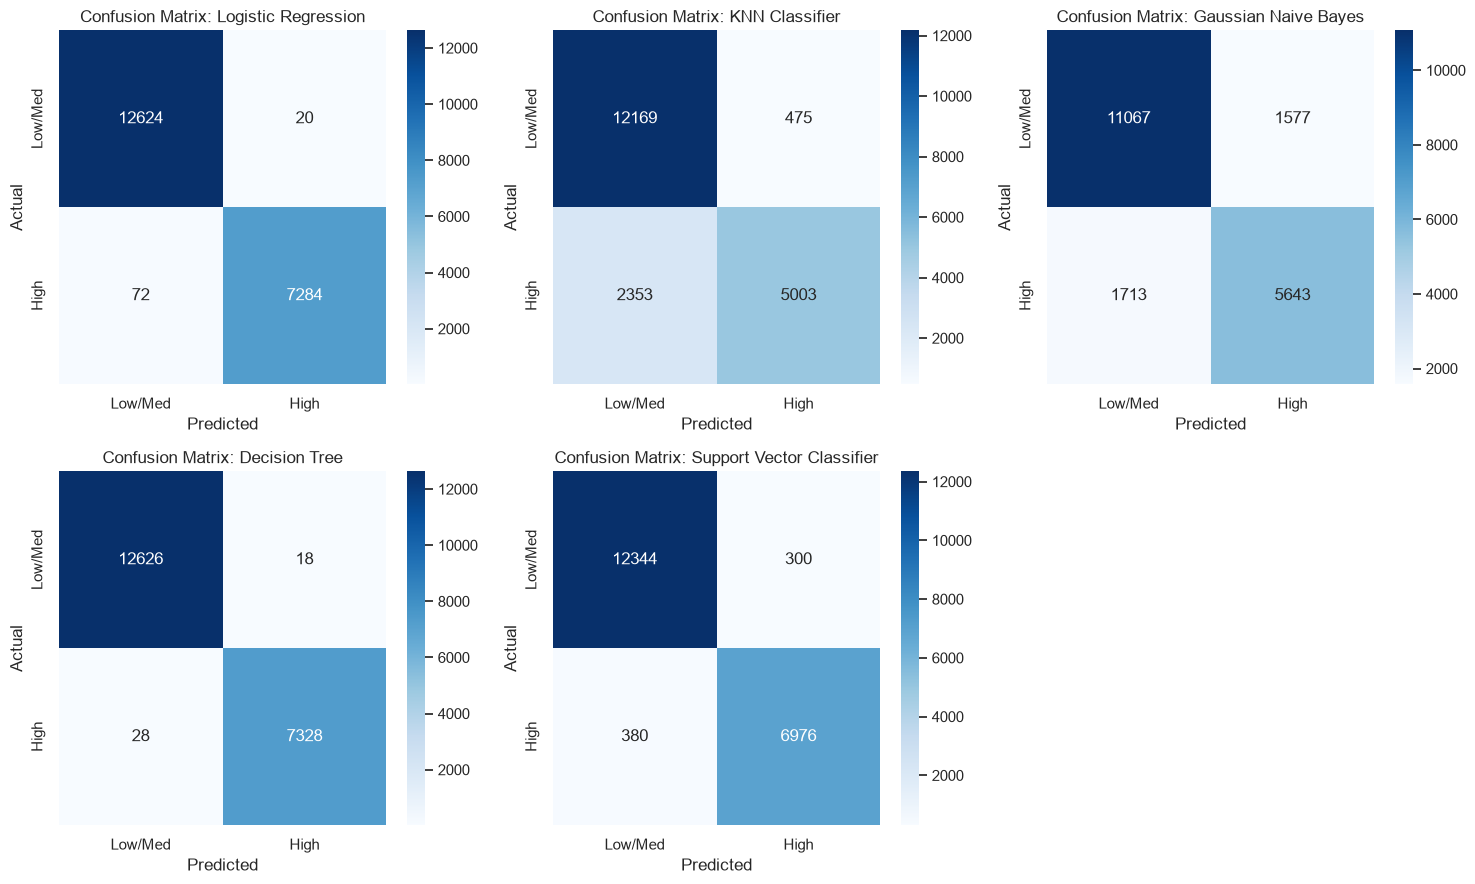

In [43]:
all_models = {'Logistic Regression': c_lr, 'KNN Classifier': c_knn, 'Gaussian Naive Bayes': c_gnb, 'Decision Tree': c_dt, 'Support Vector Classifier': c_svc}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, (name, model) in enumerate(all_models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=['Low/Med', 'High'], yticklabels=['Low/Med', 'High'])
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
axes[5].axis('off')
plt.tight_layout()
plt.show()

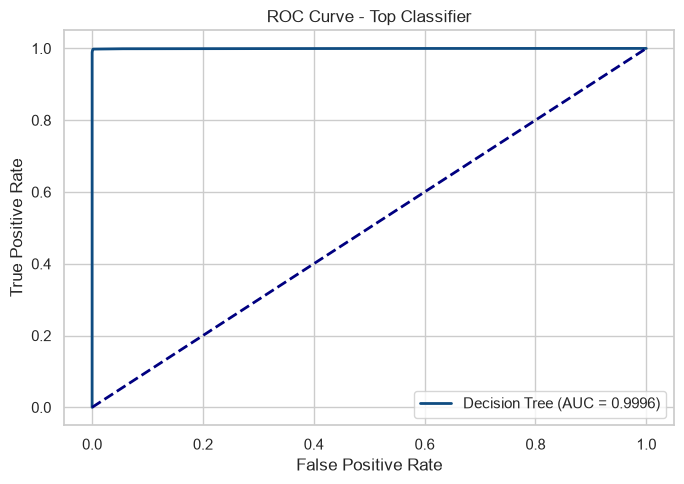

In [31]:
fpr, tpr, _ = roc_curve(y_test, prob_dt)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#0F4C81', lw=2, label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve - Top Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()